
# 09. Class-Weight Sensitivity Analysis

This notebook investigates the effect of giving the 30-day readmission class more importance during model fitting.

The experiment is intentionally narrower than the previous hyperparameter searches:

- the same cleaned dataset, 18 predictors, and 60/20/20 model-training/validation/test split are reused;
- the previously selected non-weight hyperparameters are kept fixed;
- only the positive-class weighting is changed;
- a common manual weight sequence of 1, 2, 4, 6, 8, and 10 is tested for all four models;
- model-specific automatic/reference settings such as `"balanced"` and `"balanced_subsample"` are also retained where supported;
- five-fold cross-validation on the 60% model-training set measures how class weighting affects AUPRC, AUROC, and Brier scor*;
- for every weight setting, the 20% validation set is used to choose a threshold that achieves at least 80% recall, then minimises the false-positive rate;
- detailed validation metrics are stored in a single table rather than printing many separate confusion matrices;
- one weight setting per model is selected using cross-validation AUPRC, after which its validation-selected threshold is used once on the held-out test set.


In [1]:

from pathlib import Path
from copy import deepcopy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    fbeta_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError(
        "xgboost is required for this notebook. Install it in the same "
        "environment used for the earlier XGBoost notebook."
    ) from exc

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)


## 1. Load the cleaned modelling dataset

In [2]:

PROJECT_ROOT = Path.cwd()

# Search upwards so the notebook can be run from different project subfolders.
for parent in [PROJECT_ROOT] + list(PROJECT_ROOT.parents):
    candidate = parent / "Processed_Dataset" / "diabetic_data_cleaned_stage1.csv"
    if candidate.exists():
        DATA_PATH = candidate
        PROJECT_ROOT = parent
        break
else:
    raise FileNotFoundError(
        "Could not find Processed_Dataset/diabetic_data_cleaned_stage1.csv. "
        "Run this notebook from inside the project folder, or update DATA_PATH."
    )

OUTPUT_DIR = (
    PROJECT_ROOT
    / "Model_Results"
    / "class_weight_sensitivity_analysis"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

print("Data path:", DATA_PATH)
print("Dataset shape:", df.shape)
print("Output directory:", OUTPUT_DIR)


Data path: /Users/xiaohanmu/Desktop/School/UoB/Summer Individual Project/Processing_Pipeline/Processed_Dataset/diabetic_data_cleaned_stage1.csv
Dataset shape: (69987, 56)
Output directory: /Users/xiaohanmu/Desktop/School/UoB/Summer Individual Project/Processing_Pipeline/Model_Results/class_weight_sensitivity_analysis


## 2. Reuse the same 18 predictors and binary outcome

In [3]:

# Binary target: 1 means readmitted within 30 days.
TARGET_COL = "readmitted_30"

categorical_features = [
    "gender",
    "race_group",
    "age_group",
    "admission_source_group",
    "discharge_group",
    "medical_specialty_group",
    "primary_diagnosis",
    "hba1c_group",
    "max_glu_serum",
    "diabetesMed",
]

numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
]

# Keep one explicit list of the same 18 predictors used by the tuned models.
model_features = categorical_features + numeric_features

# Fail early if an expected modelling column is missing.
missing_features = [
    feature for feature in model_features + [TARGET_COL]
    if feature not in df.columns
]

if missing_features:
    raise ValueError(
        f"Required modelling columns are missing: {missing_features}"
    )

X = df[model_features].copy()
y = df[TARGET_COL].astype(int).copy()

# Guard against raw variables, IDs or the outcome leaking into the feature matrix.
forbidden_features = {
    "race",
    "age",
    "medical_specialty",
    "diag_1",
    "A1Cresult",
    "admission_type_id",
    "admission_source_id",
    "discharge_disposition_id",
    "readmitted",
    "readmitted_30",
    "encounter_id",
    "patient_nbr",
}

unexpected_features = forbidden_features.intersection(X.columns)

assert not unexpected_features, (
    f"Unexpected or potentially leaking features found: {unexpected_features}"
)
assert not X.columns.duplicated().any()
assert len(X) == len(y)
assert y.isna().sum() == 0
assert set(y.unique()).issubset({0, 1})

print("X shape:", X.shape)
print("Number of features:", len(model_features))
print("\nTarget counts:")
print(y.value_counts())
print("\nTarget proportions:")
print(y.value_counts(normalize=True))


X shape: (69987, 18)
Number of features: 18

Target counts:
readmitted_30
0    63702
1     6285
Name: count, dtype: int64

Target proportions:
readmitted_30
0    0.910198
1    0.089802
Name: proportion, dtype: float64



## 3. Recreate the same 60/20/20 split

The first split reserves 20% as the final test set. The remaining 80% is then split 75/25, giving:

- 60% model-training data;
- 20% threshold-validation data;
- 20% final test data.

All splits are stratified and use `random_state=42`, matching the previous optimisation notebooks.


In [4]:
# Recreate the same stratified 60/20/20 development design used by the optimisation notebooks.
# First reserve test data, then split the remaining 80% into model-training and validation.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

X_model_train, X_val, y_model_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=42,
)

split_summary = pd.DataFrame({
    "split": [
        "model_train",
        "validation",
        "test",
    ],
    "rows": [
        len(X_model_train),
        len(X_val),
        len(X_test),
    ],
    "positive_count": [
        int(y_model_train.sum()),
        int(y_val.sum()),
        int(y_test.sum()),
    ],
    "positive_rate": [
        y_model_train.mean(),
        y_val.mean(),
        y_test.mean(),
    ],
})

split_summary


,split,rows,positive_count,positive_rate
0,model_train,41991,3771,0.089805
1,validation,13998,1257,0.089799
2,test,13998,1257,0.089799


## 4. Experiment settings and class-weight groups

In [5]:

RANDOM_STATE = 42
RECALL_TARGET = 0.80
# Manual sequence ranges from no extra weighting (1) to strong positive-class emphasis (10).
COMMON_POSITIVE_WEIGHTS = [1, 2, 4, 6, 8, 10]

# Five stratified folds keep the readmission proportion similar in each fold.
cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# Keep this at 1 because Random Forest and XGBoost already parallelise
# internally. This avoids nested parallelism and excessive memory use.
CV_N_JOBS = 1

negative_count = int((y_model_train == 0).sum())
positive_count = int((y_model_train == 1).sum())
# Data-driven reference: approximately how many negative cases exist for each positive case.
IMBALANCE_RATIO = negative_count / positive_count

print("Recall target:", RECALL_TARGET)
print("Common manual positive weights:", COMMON_POSITIVE_WEIGHTS)
print("Model-training negative:positive ratio:", IMBALANCE_RATIO)


Recall target: 0.8
Common manual positive weights: [1, 2, 4, 6, 8, 10]
Model-training negative:positive ratio: 10.135242641209228



### Previously selected non-weight hyperparameters

Only the class-weight parameter will change in this notebook.

- **Regularised Logistic Regression:** \(C=0.01\), L2 regularisation (`l1_ratio=0.0`).
- **Decision Tree:** depth 12, minimum split 100, minimum leaf 400, maximum 127 leaves, `max_features=0.75`, Gini criterion, no cost-complexity pruning.
- **Random Forest:** 500 trees, depth 8, minimum leaf 5, `max_features="log2"`, Gini criterion.
- **XGBoost:** depth 2, `min_child_weight=10`, `gamma=1`, `subsample=0.6`, `colsample_bytree=1.0`, `reg_alpha=1`, `reg_lambda=20`, `max_delta_step=1`, learning rate 0.1, 196 boosting rounds.

The original selected class-weight choices were:

- Logistic Regression: no additional weighting;
- Decision Tree: `"balanced"`;
- Random Forest: no additional weighting;
- XGBoost: `scale_pos_weight=6`.


In [6]:
# IMPORTANT: these are the previously selected NON-WEIGHT hyperparameters.
# They are deliberately frozen so this notebook isolates the effect of class weighting.

LOGISTIC_FIXED_PARAMS = {
    "C": 0.01,
    "l1_ratio": 0.0,
    "solver": "saga",
    "max_iter": 5000,
    "tol": 1e-3,
    "random_state": RANDOM_STATE,
}

DECISION_TREE_FIXED_PARAMS = {
    "min_samples_split": 100,
    "min_samples_leaf": 400,
    "max_leaf_nodes": 127,
    "max_features": 0.75,
    "max_depth": 12,
    "criterion": "gini",
    "ccp_alpha": 0.0,
    "random_state": RANDOM_STATE,
}

RANDOM_FOREST_FIXED_PARAMS = {
    "n_estimators": 500,
    "min_samples_split": 2,
    "min_samples_leaf": 5,
    "max_samples": None,
    "max_features": "log2",
    "max_depth": 8,
    "criterion": "gini",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

XGBOOST_FIXED_PARAMS = {
    "subsample": 0.6,
    "reg_lambda": 20.0,
    "reg_alpha": 1.0,
    "min_child_weight": 10,
    "max_depth": 2,
    "max_delta_step": 1,
    "gamma": 1.0,
    "colsample_bytree": 1.0,
    "learning_rate": 0.1,
    "n_estimators": 196,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "tree_method": "hist",
    "importance_type": "gain",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

selected_parameter_summary = pd.DataFrame([
    {
        "model": "Regularised Logistic Regression",
        "original_selected_weight": "none / ratio 1",
    },
    {
        "model": "Decision Tree",
        "original_selected_weight": "balanced",
    },
    {
        "model": "Random Forest",
        "original_selected_weight": "none / ratio 1",
    },
    {
        "model": "XGBoost",
        "original_selected_weight": "scale_pos_weight=6",
    },
])

selected_parameter_summary


,model,original_selected_weight
0,Regularised Logistic Regression,none / ratio 1
1,Decision Tree,balanced
2,Random Forest,none / ratio 1
3,XGBoost,scale_pos_weight=6


## 5. Preprocessing pipelines

In [7]:

# Categorical features: fill missing categories, then one-hot encode them.
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore"),
        ),
    ]
)

# Logistic Regression uses standardised numerical inputs because regularisation is scale-sensitive.
numeric_transformer_scaled = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

# Tree-based models do not require scaling, so their numerical branch only imputes missing values.
numeric_transformer_unscaled = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
    ]
)

# Logistic Regression receives encoded categories plus scaled numerical variables.
logistic_preprocess = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_transformer,
            categorical_features,
        ),
        (
            "numeric",
            numeric_transformer_scaled,
            numeric_features,
        ),
    ],
    remainder="drop",
)

# Decision Tree, Random Forest and XGBoost share the unscaled tree preprocessing pipeline.
tree_preprocess = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_transformer,
            categorical_features,
        ),
        (
            "numeric",
            numeric_transformer_unscaled,
            numeric_features,
        ),
    ],
    remainder="drop",
)

print("Preprocessing objects created.")


Preprocessing objects created.



## 6. Metric and threshold-selection helper functions

The detailed validation table contains both threshold-independent and threshold-dependent metrics.

**Threshold-independent**
- AUPRC
- AUROC
- Brier score
- log loss
- mean predicted probability
- approximate calibration intercept and slope

**At the validation-selected threshold**
- accuracy and balanced accuracy
- recall and precision
- specificity, false-positive rate, and false-negative rate
- F1 and F2
- TP, TN, FP, and FN
- proportion of patients flagged
- patients flagged per true readmission found


In [8]:

def calibration_intercept_and_slope(y_true, y_proba):
    """Approximate calibration intercept and slope from predicted probabilities.

    Ideal values are intercept = 0 and slope = 1.
    Intercept indicates systematic over/under-prediction; slope indicates whether
    probabilities are too extreme or too compressed. The large C makes the small
    recalibration model effectively unregularised.
    """
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    # Avoid exact 0/1 probabilities because their logit would be infinite.
    clipped = np.clip(y_proba, 1e-6, 1 - 1e-6)
    logits = np.log(clipped / (1 - clipped)).reshape(-1, 1)

    recalibration_model = LogisticRegression(
        C=1e6,
        solver="lbfgs",
        max_iter=2000,
    )
    # This fits only a small calibration check; it does not change the original prediction model.
    recalibration_model.fit(logits, y_true)

    return (
        float(recalibration_model.intercept_[0]),
        float(recalibration_model.coef_[0, 0]),
    )


def evaluate_predictions_from_proba(
    y_true,
    y_proba,
    threshold=0.5,
    model_name="Model",
):
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    # Convert continuous risk probabilities into binary predictions at the selected threshold.
    y_pred = (y_proba >= threshold).astype(int)

    # Extract the four confusion-matrix outcomes once and reuse them below.
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    total = tn + fp + fn + tp
    actual_positive = tp + fn
    actual_negative = tn + fp
    predicted_positive = tp + fp
    predicted_negative = tn + fn

    specificity = (
        tn / actual_negative
        if actual_negative > 0
        else np.nan
    )
    false_positive_rate = (
        fp / actual_negative
        if actual_negative > 0
        else np.nan
    )
    false_negative_rate = (
        fn / actual_positive
        if actual_positive > 0
        else np.nan
    )
    predicted_positive_rate = (
        predicted_positive / total
        if total > 0
        else np.nan
    )
    # Workload measure: number of patients flagged for each true readmission successfully found.
    patients_flagged_per_true_readmission = (
        predicted_positive / tp
        if tp > 0
        else np.nan
    )

    # Calibration helps detect cases where weighting mainly shifts probability scale rather than ranking.
    calibration_intercept, calibration_slope = (
        calibration_intercept_and_slope(
            y_true,
            y_proba,
        )
    )

    return {
        "model": model_name,
        "threshold": float(threshold),

        "auprc": average_precision_score(y_true, y_proba),
        "auroc": roc_auc_score(y_true, y_proba),
        "brier_score": brier_score_loss(y_true, y_proba),
        "log_loss": log_loss(
            y_true,
            np.clip(y_proba, 1e-15, 1 - 1e-15),
            labels=[0, 1],
        ),
        "observed_prevalence": float(np.mean(y_true)),
        "mean_predicted_probability": float(np.mean(y_proba)),
        "calibration_intercept": calibration_intercept,
        "calibration_slope": calibration_slope,

        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "specificity": specificity,
        "false_positive_rate": false_positive_rate,
        "false_negative_rate": false_negative_rate,
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "f2": fbeta_score(
            y_true,
            y_pred,
            beta=2,
            zero_division=0,
        ),

        "true_positive": int(tp),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "predicted_positive": int(predicted_positive),
        "predicted_negative": int(predicted_negative),
        "predicted_positive_rate": predicted_positive_rate,
        "patients_flagged_per_true_readmission_found": (
            patients_flagged_per_true_readmission
        ),
    }


def choose_threshold_for_minimum_recall(
    y_true,
    y_proba,
    min_recall=0.80,
    model_name="Model",
):
    """Choose the threshold with the lowest FPR subject to recall >= target.

    Tie-breaker: use the highest threshold.
    """
    # Generate every available ROC operating point instead of only a coarse threshold grid.
    false_positive_rates, recalls, thresholds = roc_curve(
        y_true,
        y_proba,
        drop_intermediate=False,
    )

    candidate_table = pd.DataFrame({
        "threshold": thresholds,
        "recall": recalls,
        "false_positive_rate": false_positive_rates,
        "specificity": 1 - false_positive_rates,
    })

    candidate_table = candidate_table[
        np.isfinite(candidate_table["threshold"])
    ].copy()

    # Discard thresholds that fail to reach the minimum recall requirement.
    eligible_candidates = candidate_table[
        candidate_table["recall"] >= min_recall
    ].copy()

    if eligible_candidates.empty:
        raise ValueError(
            f"No threshold achieved recall >= {min_recall:.2f}."
        )

    # Among eligible thresholds, minimise FPR; if tied, choose the higher threshold.
    eligible_candidates = (
        eligible_candidates
        .sort_values(
            by=[
                "false_positive_rate",
                "threshold",
            ],
            ascending=[
                True,
                False,
            ],
        )
        .reset_index(drop=True)
    )

    selected_threshold = float(
        eligible_candidates.iloc[0]["threshold"]
    )

    # Recalculate the full validation metric set at the chosen operating point.
    selected_metrics = evaluate_predictions_from_proba(
        y_true=y_true,
        y_proba=y_proba,
        threshold=selected_threshold,
        model_name=model_name,
    )

    return (
        selected_threshold,
        selected_metrics,
        eligible_candidates,
    )


## 7. Define the weight settings

In [9]:

def sklearn_manual_class_weight(positive_weight):
    """Convert a positive-class multiplier to sklearn's class_weight format.

    Class 0 always has weight 1. For example, positive_weight=6 makes an error
    on a readmitted patient contribute roughly six times the weight of an error
    on a non-readmitted patient during fitting.
    """
    if positive_weight == 1:
        # This exactly reproduces an unweighted sklearn classifier.
        return None
    return {0: 1, 1: float(positive_weight)}


# Build the common manual sequence 1, 2, 4, 6, 8 and 10.
logistic_weight_settings = [
    {
        "weight_label": f"manual_{weight}",
        "weight_type": "manual",
        "positive_to_negative_ratio": float(weight),
        "parameter_value": sklearn_manual_class_weight(weight),
    }
    for weight in COMMON_POSITIVE_WEIGHTS
]

# Add sklearn's automatic `balanced` reference, derived from inverse class frequencies.
logistic_weight_settings.append({
    "weight_label": "balanced",
    "weight_type": "automatic_reference",
    "positive_to_negative_ratio": float(IMBALANCE_RATIO),
    "parameter_value": "balanced",
})


# Decision Tree supports the same manual and automatic `balanced` settings.
decision_tree_weight_settings = deepcopy(logistic_weight_settings)


# Random Forest adds `balanced_subsample`, which recalculates weights inside each bootstrap sample/tree.
random_forest_weight_settings = deepcopy(logistic_weight_settings)
random_forest_weight_settings.append({
    "weight_label": "balanced_subsample",
    "weight_type": "automatic_reference",
    "positive_to_negative_ratio": float(IMBALANCE_RATIO),
    "parameter_value": "balanced_subsample",
})


# XGBoost expresses the same idea using `scale_pos_weight` instead of sklearn class_weight.
xgboost_weight_settings = [
    {
        "weight_label": f"manual_{weight}",
        "weight_type": "manual",
        "positive_to_negative_ratio": float(weight),
        "parameter_value": float(weight),
    }
    for weight in COMMON_POSITIVE_WEIGHTS
]

# The original XGBoost search also included the exact observed negative:positive class ratio.
xgboost_weight_settings.append({
    "weight_label": "imbalance_ratio_reference",
    "weight_type": "automatic_reference",
    "positive_to_negative_ratio": float(IMBALANCE_RATIO),
    "parameter_value": float(IMBALANCE_RATIO),
})


weight_setting_counts = pd.DataFrame({
    "model": [
        "Regularised Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
    ],
    "number_of_weight_settings": [
        len(logistic_weight_settings),
        len(decision_tree_weight_settings),
        len(random_forest_weight_settings),
        len(xgboost_weight_settings),
    ],
})

weight_setting_counts


,model,number_of_weight_settings
0,Regularised Logistic Regression,7
1,Decision Tree,7
2,Random Forest,8
3,XGBoost,7


## 8. Model builders with fixed non-weight hyperparameters

In [10]:

def build_logistic_model(class_weight):
    """Build Logistic Regression with fixed non-weight settings and one chosen class weight."""
    return Pipeline(
        steps=[
            (
                "preprocess",
                clone(logistic_preprocess),
            ),
            (
                "model",
                LogisticRegression(
                    class_weight=class_weight,
                    **LOGISTIC_FIXED_PARAMS,
                ),
            ),
        ]
    )


def build_decision_tree_model(class_weight):
    """Build the fixed Decision Tree while changing only its class-weight setting."""
    return Pipeline(
        steps=[
            (
                "preprocess",
                clone(tree_preprocess),
            ),
            (
                "model",
                DecisionTreeClassifier(
                    class_weight=class_weight,
                    **DECISION_TREE_FIXED_PARAMS,
                ),
            ),
        ]
    )


def build_random_forest_model(class_weight):
    """Build the fixed Random Forest while changing only its class-weight setting."""
    return Pipeline(
        steps=[
            (
                "preprocess",
                clone(tree_preprocess),
            ),
            (
                "model",
                RandomForestClassifier(
                    class_weight=class_weight,
                    **RANDOM_FOREST_FIXED_PARAMS,
                ),
            ),
        ]
    )


def build_xgboost_model(scale_pos_weight):
    """Build the fixed XGBoost model while changing only scale_pos_weight."""
    return Pipeline(
        steps=[
            (
                "preprocess",
                clone(tree_preprocess),
            ),
            (
                "model",
                XGBClassifier(
                    scale_pos_weight=scale_pos_weight,
                    **XGBOOST_FIXED_PARAMS,
                ),
            ),
        ]
    )


# Registry links each model to its builder, tested weights and earlier selected weight.
model_experiments = {
    "Regularised Logistic Regression": {
        "builder": build_logistic_model,
        "weight_settings": logistic_weight_settings,
        "original_weight_label": "manual_1",
    },
    "Decision Tree": {
        "builder": build_decision_tree_model,
        "weight_settings": decision_tree_weight_settings,
        "original_weight_label": "balanced",
    },
    "Random Forest": {
        "builder": build_random_forest_model,
        "weight_settings": random_forest_weight_settings,
        "original_weight_label": "manual_1",
    },
    "XGBoost": {
        "builder": build_xgboost_model,
        "weight_settings": xgboost_weight_settings,
        "original_weight_label": "manual_6",
    },
}

print("Model builders created.")


Model builders created.



## 9. Cross-validation and validation experiment functions

For each weight setting:

1. run five-fold stratified cross-validation on the model-training data;
2. record mean and standard deviation for AUPRC, AUROC, and Brier score;
3. refit the model on the complete model-training set;
4. obtain validation probabilities;
5. select the validation threshold satisfying recall >= 80% with the lowest FPR;
6. store the full validation statistics in one row.

This means the notebook stays compact even though a large set of statistics is retained.


In [11]:

# Track ranking quality (AUPRC/AUROC) and probability quality (Brier) in every fold.
CV_SCORING = {
    "auprc": "average_precision",
    "auroc": "roc_auc",
    "neg_brier": "neg_brier_score",
}


def run_cross_validation(model):
    """Run the same five-fold CV evaluation for one model/weight configuration."""
    # The complete pipeline is refitted independently inside every fold.
    cv_results = cross_validate(
        estimator=model,
        X=X_model_train,
        y=y_model_train,
        scoring=CV_SCORING,
        cv=cross_validation,
        n_jobs=CV_N_JOBS,
        return_train_score=False,
        error_score="raise",
    )

    return {
        # Mean = overall CV performance; standard deviation = fold-to-fold stability.
        "cv_mean_auprc": np.mean(cv_results["test_auprc"]),
        "cv_std_auprc": np.std(cv_results["test_auprc"]),
        "cv_mean_auroc": np.mean(cv_results["test_auroc"]),
        "cv_std_auroc": np.std(cv_results["test_auroc"]),
        "cv_mean_brier": -np.mean(cv_results["test_neg_brier"]),
        "cv_std_brier": np.std(-cv_results["test_neg_brier"]),
    }


def run_one_weight_configuration(
    model_name,
    builder,
    weight_setting,
):
    """Run the full development experiment for one class-weight setting.

    The function performs five-fold CV, refits the model on all model-training
    data, obtains validation probabilities, selects the >=80%-recall threshold,
    and returns one combined CV + validation result row.
    """
    model = builder(weight_setting["parameter_value"])

    # These CV metrics are what later decide which class weight is selected.
    cv_metrics = run_cross_validation(model)

    # Refit this weight configuration on the full 60% model-training subset.
    model.fit(
        X_model_train,
        y_model_train,
    )

    # Validation probabilities are used for threshold selection and sensitivity reporting.
    y_val_proba = model.predict_proba(X_val)[:, 1]

    (
        selected_threshold,
        validation_metrics,
        eligible_thresholds,
    ) = choose_threshold_for_minimum_recall(
        y_true=y_val,
        y_proba=y_val_proba,
        min_recall=RECALL_TARGET,
        model_name=model_name,
    )

    # Merge model-training CV results with validation operating-point metrics.
    result = {
        "model": model_name,
        "weight_label": weight_setting["weight_label"],
        "weight_type": weight_setting["weight_type"],
        "positive_to_negative_ratio": (
            weight_setting["positive_to_negative_ratio"]
        ),
        **cv_metrics,
        **{
            f"val_{key}": value
            for key, value in validation_metrics.items()
            if key != "model"
        },
    }

    return result, model, eligible_thresholds



## 10. Run the sensitivity analysis

**Runtime note:** this is much smaller than the earlier hyperparameter searches, but Random Forest still fits 500 trees in each cross-validation fold. Depending on the computer, the whole cell may take a while. The cell prints only one short progress line per configuration; the detailed results are collected into dataframes.


In [12]:
# Outer loop = model type; inner loop = class-weight setting.
# Every configuration follows exactly the same CV, refit and validation-threshold procedure.

all_results = []
fitted_validation_models = {}
eligible_threshold_tables = {}

for model_name, experiment in model_experiments.items():
    print(f"\n=== {model_name} ===")

    # Test every supported manual/automatic weight for this model.
    for weight_setting in experiment["weight_settings"]:
        label = weight_setting["weight_label"]
        ratio = weight_setting["positive_to_negative_ratio"]

        print(
            f"Running {label} "
            f"(positive:negative ratio ~ {ratio:.3f})"
        )

        # One helper call runs CV, full-training refit, validation probabilities and threshold selection.
        (
            result,
            fitted_model,
            eligible_thresholds,
        ) = run_one_weight_configuration(
            model_name=model_name,
            builder=experiment["builder"],
            weight_setting=weight_setting,
        )

        all_results.append(result)
        # Keep fitted models and eligible thresholds for later inspection without rerunning.
        fitted_validation_models[
            (model_name, label)
        ] = fitted_model
        eligible_threshold_tables[
            (model_name, label)
        ] = eligible_thresholds

class_weight_results = pd.DataFrame(all_results)

print("\nSensitivity analysis complete.")
print("Rows produced:", len(class_weight_results))



=== Regularised Logistic Regression ===
Running manual_1 (positive:negative ratio ~ 1.000)
Running manual_2 (positive:negative ratio ~ 2.000)
Running manual_4 (positive:negative ratio ~ 4.000)
Running manual_6 (positive:negative ratio ~ 6.000)
Running manual_8 (positive:negative ratio ~ 8.000)
Running manual_10 (positive:negative ratio ~ 10.000)
Running balanced (positive:negative ratio ~ 10.135)

=== Decision Tree ===
Running manual_1 (positive:negative ratio ~ 1.000)
Running manual_2 (positive:negative ratio ~ 2.000)
Running manual_4 (positive:negative ratio ~ 4.000)
Running manual_6 (positive:negative ratio ~ 6.000)
Running manual_8 (positive:negative ratio ~ 8.000)
Running manual_10 (positive:negative ratio ~ 10.000)
Running balanced (positive:negative ratio ~ 10.135)

=== Random Forest ===
Running manual_1 (positive:negative ratio ~ 1.000)
Running manual_2 (positive:negative ratio ~ 2.000)
Running manual_4 (positive:negative ratio ~ 4.000)
Running manual_6 (positive:negative rati

## 11. Compact comparison table

In [13]:
# Compact table: the main CV and validation measures used for quick comparison.

compact_columns = [
    "model",
    "weight_label",
    "weight_type",
    "positive_to_negative_ratio",
    "cv_mean_auprc",
    "cv_std_auprc",
    "cv_mean_auroc",
    "cv_std_auroc",
    "cv_mean_brier",
    "val_threshold",
    "val_auprc",
    "val_auroc",
    "val_brier_score",
    "val_recall",
    "val_precision",
    "val_specificity",
    "val_false_positive_rate",
    "val_f2",
    "val_balanced_accuracy",
    "val_predicted_positive_rate",
]

compact_results = (
    class_weight_results[
        compact_columns
    ]
    .sort_values(
        by=[
            "model",
            "positive_to_negative_ratio",
            "weight_label",
        ]
    )
    .reset_index(drop=True)
)

compact_results


,model,weight_label,weight_type,positive_to_negative_ratio,cv_mean_auprc,cv_std_auprc,cv_mean_auroc,cv_std_auroc,cv_mean_brier,val_threshold,val_auprc,val_auroc,val_brier_score,val_recall,val_precision,val_specificity,val_false_positive_rate,val_f2,val_balanced_accuracy,val_predicted_positive_rate
0,Decision Tree,manual_1,manual,1.000000,0.140144,0.003233,0.616996,0.003785,0.080473,0.060227,0.129506,0.607700,0.080911,0.817025,0.103518,0.301939,0.698061,0.343501,0.559482,0.708744
1,Decision Tree,manual_2,manual,2.000000,0.139107,0.002955,0.616442,0.006930,0.087124,0.122653,0.127176,0.600928,0.088058,0.801909,0.105760,0.331057,0.668943,0.346178,0.566483,0.680883
2,Decision Tree,manual_4,manual,4.000000,0.139641,0.002519,0.620971,0.004936,0.118369,0.206452,0.129882,0.606825,0.119222,0.804296,0.107427,0.340711,0.659289,0.350093,0.572504,0.672310
3,Decision Tree,manual_6,manual,6.000000,0.138094,0.003605,0.617306,0.005650,0.157649,0.283368,0.126932,0.598742,0.158345,0.807478,0.103773,0.311985,0.688015,0.342697,0.559732,0.698743
4,Decision Tree,manual_8,manual,8.000000,0.138749,0.003379,0.617859,0.003610,0.196183,0.345216,0.128436,0.600432,0.197446,0.814638,0.102822,0.298721,0.701279,0.341629,0.556679,0.711459
5,Decision Tree,manual_10,manual,10.000000,0.137828,0.002297,0.613411,0.006562,0.233181,0.405028,0.126401,0.603447,0.234909,0.801909,0.103853,0.317322,0.682678,0.342066,0.559616,0.693385
6,Decision Tree,balanced,automatic_reference,10.135243,0.139804,0.000904,0.618651,0.005896,0.235615,0.400458,0.126662,0.599779,0.237078,0.808274,0.103790,0.311436,0.688564,0.342849,0.559855,0.699314
7,Random Forest,manual_1,manual,1.000000,0.152075,0.006281,0.636290,0.007688,0.080106,0.070438,0.139610,0.622744,0.080447,0.800318,0.109051,0.354917,0.645083,0.352908,0.577618,0.659023
8,Random Forest,manual_2,manual,2.000000,0.151359,0.004759,0.636181,0.007529,0.085235,0.131279,0.140010,0.623476,0.085745,0.800318,0.109550,0.358214,0.641786,0.353951,0.579266,0.656022
9,Random Forest,manual_4,manual,4.000000,0.150707,0.005437,0.636117,0.006639,0.114042,0.229131,0.139278,0.623115,0.115027,0.800318,0.109300,0.356565,0.643435,0.353429,0.578442,0.657523



## 12. Full statistics table

Use this table when Dalila wants the complete details. It includes confusion-matrix counts and calibration-related measures, but it is kept as one dataframe instead of producing a separate output block for every model and weight.


In [14]:
# Full table: preserves calibration, confusion-matrix and workload measures for deeper analysis.

full_columns = [
    "model",
    "weight_label",
    "weight_type",
    "positive_to_negative_ratio",

    "cv_mean_auprc",
    "cv_std_auprc",
    "cv_mean_auroc",
    "cv_std_auroc",
    "cv_mean_brier",
    "cv_std_brier",

    "val_threshold",
    "val_auprc",
    "val_auroc",
    "val_brier_score",
    "val_log_loss",
    "val_observed_prevalence",
    "val_mean_predicted_probability",
    "val_calibration_intercept",
    "val_calibration_slope",

    "val_accuracy",
    "val_balanced_accuracy",
    "val_recall",
    "val_precision",
    "val_specificity",
    "val_false_positive_rate",
    "val_false_negative_rate",
    "val_f1",
    "val_f2",

    "val_true_positive",
    "val_true_negative",
    "val_false_positive",
    "val_false_negative",
    "val_predicted_positive",
    "val_predicted_negative",
    "val_predicted_positive_rate",
    "val_patients_flagged_per_true_readmission_found",
]

full_results = (
    class_weight_results[
        full_columns
    ]
    .sort_values(
        by=[
            "model",
            "positive_to_negative_ratio",
            "weight_label",
        ]
    )
    .reset_index(drop=True)
)

full_results


,model,weight_label,weight_type,positive_to_negative_ratio,cv_mean_auprc,cv_std_auprc,cv_mean_auroc,cv_std_auroc,cv_mean_brier,cv_std_brier,val_threshold,val_auprc,val_auroc,val_brier_score,val_log_loss,val_observed_prevalence,val_mean_predicted_probability,val_calibration_intercept,val_calibration_slope,val_accuracy,val_balanced_accuracy,val_recall,val_precision,val_specificity,val_false_positive_rate,val_false_negative_rate,val_f1,val_f2,val_true_positive,val_true_negative,val_false_positive,val_false_negative,val_predicted_positive,val_predicted_negative,val_predicted_positive_rate,val_patients_flagged_per_true_readmission_found
0,Decision Tree,manual_1,manual,1.000000,0.140144,0.003233,0.616996,0.003785,0.080473,0.000112,0.060227,0.129506,0.607700,0.080911,0.297615,0.089799,0.089649,-0.765352,0.655949,0.348193,0.559482,0.817025,0.103518,0.301939,0.698061,0.182975,0.183754,0.343501,1027,3847,8894,230,9921,4077,0.708744,9.660175
1,Decision Tree,manual_2,manual,2.000000,0.139107,0.002955,0.616442,0.006930,0.087124,0.000137,0.122653,0.127176,0.600928,0.088058,0.321560,0.089799,0.161894,-1.269232,0.627312,0.373339,0.566483,0.801909,0.105760,0.331057,0.668943,0.198091,0.186874,0.346178,1008,4218,8523,249,9531,4467,0.680883,9.455357
2,Decision Tree,manual_4,manual,4.000000,0.139641,0.002519,0.620971,0.004936,0.118369,0.000540,0.206452,0.129882,0.606825,0.119222,0.405506,0.089799,0.270518,-1.678650,0.652486,0.382340,0.572504,0.804296,0.107427,0.340711,0.659289,0.195704,0.189539,0.350093,1011,4341,8400,246,9411,4587,0.672310,9.308605
3,Decision Tree,manual_6,manual,6.000000,0.138094,0.003605,0.617306,0.005650,0.157649,0.001035,0.283368,0.126932,0.598742,0.158345,0.495748,0.089799,0.351406,-1.960890,0.614841,0.356479,0.559732,0.807478,0.103773,0.311985,0.688015,0.192522,0.183910,0.342697,1015,3975,8766,242,9781,4217,0.698743,9.636453
4,Decision Tree,manual_8,manual,8.000000,0.138749,0.003379,0.617859,0.003610,0.196183,0.000575,0.345216,0.128436,0.600432,0.197446,0.580659,0.089799,0.414795,-2.138576,0.615972,0.345049,0.556679,0.814638,0.102822,0.298721,0.701279,0.185362,0.182596,0.341629,1024,3806,8935,233,9959,4039,0.711459,9.725586
5,Decision Tree,manual_10,manual,10.000000,0.137828,0.002297,0.613411,0.006562,0.233181,0.000552,0.405028,0.126401,0.603447,0.234909,0.660918,0.089799,0.467831,-2.280413,0.647035,0.360837,0.559616,0.801909,0.103853,0.317322,0.682678,0.198091,0.183891,0.342066,1008,4043,8698,249,9706,4292,0.693385,9.628968
6,Decision Tree,balanced,automatic_reference,10.135243,0.139804,0.000904,0.618651,0.005896,0.235615,0.000988,0.400458,0.126662,0.599779,0.237078,0.665189,0.089799,0.469452,-2.285459,0.614816,0.356051,0.559855,0.808274,0.103790,0.311436,0.688564,0.191726,0.183958,0.342849,1016,3968,8773,241,9789,4209,0.699314,9.634843
7,Random Forest,manual_1,manual,1.000000,0.152075,0.006281,0.636290,0.007688,0.080106,0.000131,0.070438,0.139610,0.622744,0.080447,0.294531,0.089799,0.089775,0.483414,1.214570,0.394914,0.577618,0.800318,0.109051,0.354917,0.645083,0.199682,0.191948,0.352908,1006,4522,8219,251,9225,4773,0.659023,9.169980
8,Random Forest,manual_2,manual,2.000000,0.151359,0.004759,0.636181,0.007529,0.085235,0.000142,0.131279,0.140010,0.623476,0.085745,0.317012,0.089799,0.161924,-0.296339,1.245091,0.397914,0.579266,0.800318,0.109550,0.358214,0.641786,0.199682,0.192720,0.353951,1006,4564,8177,251,9183,4815,0.656022,9.128231
9,Random Forest,manual_4,manual,4.000000,0.150707,0.005437,0.636117,0.006639,0.114042,0.000148,0.229131,0.139278,0.623115,0.115027,0.401029,0.089799,0.272635,-1.147085,1.237320,0.396414,0.578442,0.800318,0.109300,0.356565,0.643435,0.199682,0.192333,0.353429,1006,4543,8198,251,9204,4794,0.657523,9.149105



## 13. Select one class-weight setting per model

The class weight is treated as a **model hyperparameter**, so the selection is based on model-training cross-validation rather than on the test set.

Selection rule:

1. maximise mean five-fold CV AUPRC;
2. if tied, maximise mean CV AUROC;
3. if still tied, minimise mean CV Brier score.

After the weight is selected, its already-computed validation threshold is retained.

The validation FPR/precision/F2 for every other weight remain useful for interpretation, but they do not decide the class-weight hyperparameter.


In [15]:
# Select ONE class-weight hyperparameter per model using model-training cross-validation only.

selected_weight_rows = []

for model_name in model_experiments:
    model_rows = class_weight_results[
        class_weight_results["model"] == model_name
    ].copy()

    # Priority: highest CV AUPRC, then highest AUROC, then lowest Brier score.
    selected_row = (
        model_rows
        .sort_values(
            by=[
                "cv_mean_auprc",
                "cv_mean_auroc",
                "cv_mean_brier",
            ],
            ascending=[
                False,
                False,
                True,
            ],
        )
        .iloc[0]
    )

    selected_weight_rows.append(selected_row)

selected_weights = (
    pd.DataFrame(selected_weight_rows)
    .reset_index(drop=True)
)

selection_columns = [
    "model",
    "weight_label",
    "weight_type",
    "positive_to_negative_ratio",
    "cv_mean_auprc",
    "cv_mean_auroc",
    "cv_mean_brier",
    "val_threshold",
    "val_recall",
    "val_precision",
    "val_false_positive_rate",
    "val_f2",
    "val_brier_score",
    "val_calibration_intercept",
    "val_calibration_slope",
]

selected_weights[selection_columns]


,model,weight_label,weight_type,positive_to_negative_ratio,cv_mean_auprc,cv_mean_auroc,cv_mean_brier,val_threshold,val_recall,val_precision,val_false_positive_rate,val_f2,val_brier_score,val_calibration_intercept,val_calibration_slope
0,Regularised Logistic Regression,manual_2,manual,2.0,0.151550,0.633173,0.085908,0.125560,0.800318,0.110647,0.634644,0.356232,0.086709,-0.889562,0.873775
1,Decision Tree,manual_1,manual,1.0,0.140144,0.616996,0.080473,0.060227,0.817025,0.103518,0.698061,0.343501,0.080911,-0.765352,0.655949
2,Random Forest,manual_1,manual,1.0,0.152075,0.636290,0.080106,0.070438,0.800318,0.109051,0.645083,0.352908,0.080447,0.483414,1.214570
3,XGBoost,manual_10,manual,10.0,0.151909,0.634852,0.228630,0.406985,0.800318,0.110102,0.638176,0.355101,0.230797,-2.283873,0.875756



### Compare the newly selected weight with the weight chosen in the earlier broad tuning

This table is particularly useful for answering the supervisor's question about why some models previously selected no additional weighting while others selected stronger positive-class weights.


In [16]:
# Compare the dedicated sensitivity-analysis choice with the class weight chosen earlier
# during the broader model hyperparameter search.

original_vs_new_rows = []

for model_name, experiment in model_experiments.items():
    original_label = experiment["original_weight_label"]

    # Retrieve the earlier choice and the newly CV-selected weight for the same model.
    original_row = class_weight_results[
        (class_weight_results["model"] == model_name)
        & (class_weight_results["weight_label"] == original_label)
    ].iloc[0]

    new_row = selected_weights[
        selected_weights["model"] == model_name
    ].iloc[0]

    original_vs_new_rows.append({
        "model": model_name,
        "original_weight": original_label,
        "new_cv_selected_weight": new_row["weight_label"],

        "original_cv_auprc": original_row["cv_mean_auprc"],
        "new_cv_auprc": new_row["cv_mean_auprc"],
        "cv_auprc_change": (
            new_row["cv_mean_auprc"]
            - original_row["cv_mean_auprc"]
        ),

        "original_val_fpr": original_row["val_false_positive_rate"],
        "new_val_fpr": new_row["val_false_positive_rate"],
        "val_fpr_change": (
            new_row["val_false_positive_rate"]
            - original_row["val_false_positive_rate"]
        ),

        "original_val_precision": original_row["val_precision"],
        "new_val_precision": new_row["val_precision"],

        "original_val_brier": original_row["val_brier_score"],
        "new_val_brier": new_row["val_brier_score"],
    })

original_vs_new = pd.DataFrame(original_vs_new_rows)
original_vs_new


,model,original_weight,new_cv_selected_weight,original_cv_auprc,new_cv_auprc,cv_auprc_change,original_val_fpr,new_val_fpr,val_fpr_change,original_val_precision,new_val_precision,original_val_brier,new_val_brier
0,Regularised Logistic Regression,manual_1,manual_2,0.151475,0.151550,0.000075,0.639432,0.634644,-0.004788,0.109909,0.110647,0.080635,0.086709
1,Decision Tree,balanced,manual_1,0.139804,0.140144,0.000340,0.688564,0.698061,0.009497,0.103790,0.103518,0.237078,0.080911
2,Random Forest,manual_1,manual_1,0.152075,0.152075,0.000000,0.645083,0.645083,0.000000,0.109051,0.109051,0.080447,0.080447
3,XGBoost,manual_6,manual_10,0.151465,0.151909,0.000443,0.641786,0.638176,-0.003610,0.109550,0.110102,0.155444,0.230797


## 14. Visualise the class-weight trends

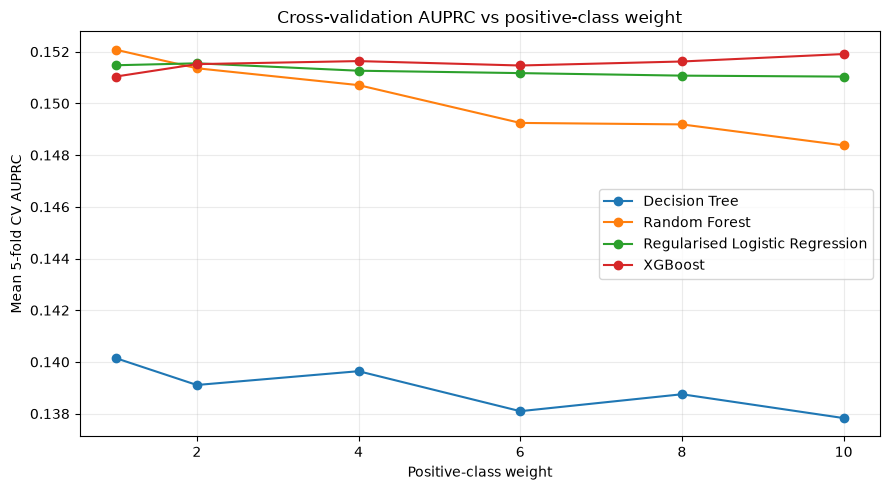

In [17]:
# Plot only the common manual weights so all four models share a directly comparable x-axis.

manual_results = class_weight_results[
    class_weight_results["weight_type"] == "manual"
].copy()

fig, ax = plt.subplots(figsize=(9, 5))

for model_name, group in manual_results.groupby("model"):
    group = group.sort_values("positive_to_negative_ratio")
    # Shows whether stronger positive weighting changes ranking quality.
    ax.plot(
        group["positive_to_negative_ratio"],
        group["cv_mean_auprc"],
        marker="o",
        label=model_name,
    )

ax.set_xlabel("Positive-class weight")
ax.set_ylabel("Mean 5-fold CV AUPRC")
ax.set_title("Cross-validation AUPRC vs positive-class weight")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()

auprc_plot_path = OUTPUT_DIR / "class_weight_cv_auprc.png"
plt.savefig(auprc_plot_path, dpi=200, bbox_inches="tight")
plt.show()


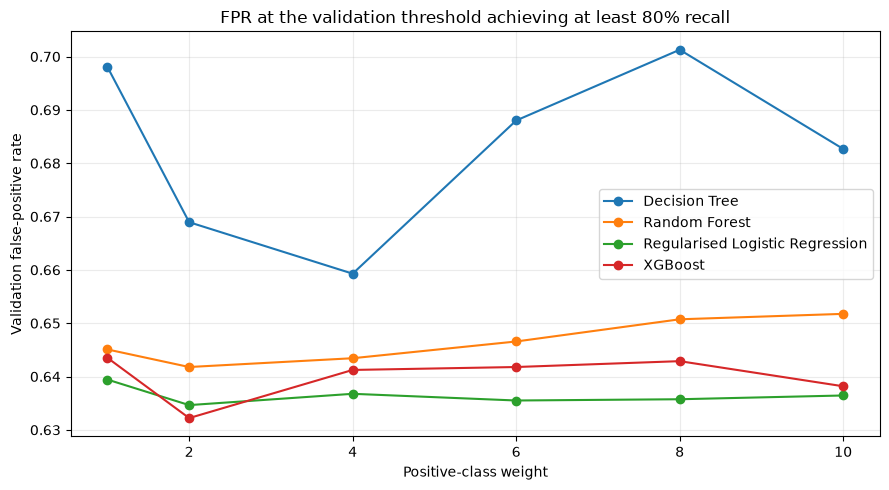

In [18]:
# Each weight receives its own >=80%-recall threshold first; this plot then compares
# the resulting false-positive burden at that common recall target.

fig, ax = plt.subplots(figsize=(9, 5))

for model_name, group in manual_results.groupby("model"):
    group = group.sort_values("positive_to_negative_ratio")
    ax.plot(
        group["positive_to_negative_ratio"],
        group["val_false_positive_rate"],
        marker="o",
        label=model_name,
    )

ax.set_xlabel("Positive-class weight")
ax.set_ylabel("Validation false-positive rate")
ax.set_title("FPR at the validation threshold achieving at least 80% recall")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()

fpr_plot_path = OUTPUT_DIR / "class_weight_validation_fpr.png"
plt.savefig(fpr_plot_path, dpi=200, bbox_inches="tight")
plt.show()


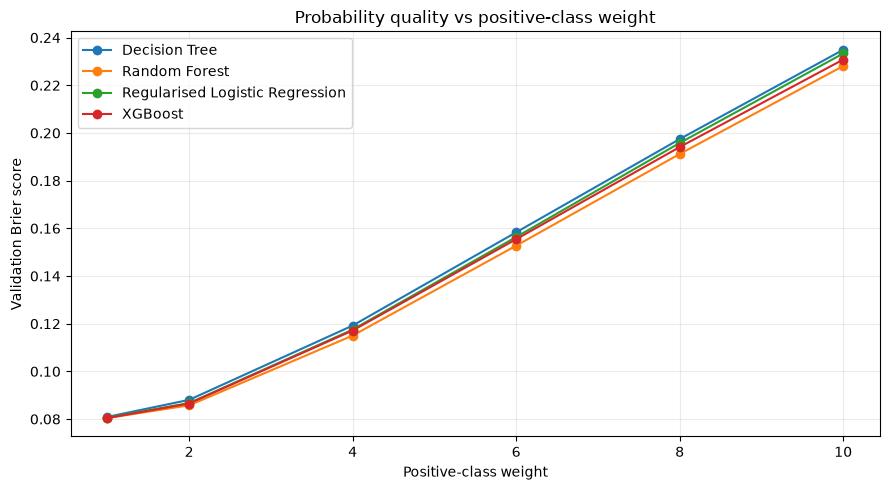

In [19]:
# Lower Brier score is better. This plot checks whether weighting harms or improves
# the quality/calibration of predicted probabilities.

fig, ax = plt.subplots(figsize=(9, 5))

for model_name, group in manual_results.groupby("model"):
    group = group.sort_values("positive_to_negative_ratio")
    ax.plot(
        group["positive_to_negative_ratio"],
        group["val_brier_score"],
        marker="o",
        label=model_name,
    )

ax.set_xlabel("Positive-class weight")
ax.set_ylabel("Validation Brier score")
ax.set_title("Probability quality vs positive-class weight")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()

brier_plot_path = OUTPUT_DIR / "class_weight_validation_brier.png"
plt.savefig(brier_plot_path, dpi=200, bbox_inches="tight")
plt.show()



## 15. Final test evaluation of the CV-selected weight only

**Important:** the test set is not used to compare all class weights.

For each model:

1. take the weight selected using five-fold CV AUPRC;
2. use the threshold that was selected for that same weight on the validation set;
3. refit that configuration on the full 60% model-training data;
4. evaluate once on the held-out test set.

Do not change the class weight or threshold after inspecting these results.


In [20]:
# Test only the single CV-selected weight per model. Alternative weights remain
# development/sensitivity results and are not compared on the held-out test set.

final_test_rows = []
final_test_confusion_matrices = {}

for _, selected_row in selected_weights.iterrows():
    model_name = selected_row["model"]
    weight_label = selected_row["weight_label"]
    # Carry forward the threshold already selected for this same weight on validation data.
    selected_threshold = float(selected_row["val_threshold"])

    experiment = model_experiments[model_name]

    weight_setting = next(
        setting
        for setting in experiment["weight_settings"]
        if setting["weight_label"] == weight_label
    )

    # Rebuild the model using its fixed non-weight hyperparameters plus the selected weight.
    final_model = experiment["builder"](
        weight_setting["parameter_value"]
    )

    # Fit once on the full model-training subset before the one-off test evaluation.
    final_model.fit(
        X_model_train,
        y_model_train,
    )

    # Apply the already-locked validation threshold to these final test probabilities.
    y_test_proba = final_model.predict_proba(X_test)[:, 1]

    # No class weight or threshold is changed after the test result is observed.
    test_metrics = evaluate_predictions_from_proba(
        y_true=y_test,
        y_proba=y_test_proba,
        threshold=selected_threshold,
        model_name=model_name,
    )

    test_metrics.update({
        "weight_label": weight_label,
        "weight_type": weight_setting["weight_type"],
        "positive_to_negative_ratio": (
            weight_setting["positive_to_negative_ratio"]
        ),
    })

    final_test_rows.append(test_metrics)

    y_test_pred = (
        y_test_proba >= selected_threshold
    ).astype(int)

    cm = confusion_matrix(
        y_test,
        y_test_pred,
        labels=[0, 1],
    )

    final_test_confusion_matrices[model_name] = pd.DataFrame(
        cm,
        index=[
            "Actual not readmitted",
            "Actual readmitted",
        ],
        columns=[
            "Predicted not readmitted",
            "Predicted readmitted",
        ],
    )

final_test_results = pd.DataFrame(final_test_rows)

final_test_columns = [
    "model",
    "weight_label",
    "positive_to_negative_ratio",
    "threshold",
    "auprc",
    "auroc",
    "brier_score",
    "log_loss",
    "calibration_intercept",
    "calibration_slope",
    "recall",
    "precision",
    "specificity",
    "false_positive_rate",
    "f1",
    "f2",
    "balanced_accuracy",
    "true_positive",
    "true_negative",
    "false_positive",
    "false_negative",
    "predicted_positive_rate",
    "patients_flagged_per_true_readmission_found",
]

final_test_results[final_test_columns]


,model,weight_label,positive_to_negative_ratio,threshold,auprc,auroc,brier_score,log_loss,calibration_intercept,calibration_slope,recall,precision,specificity,false_positive_rate,f1,f2,balanced_accuracy,true_positive,true_negative,false_positive,false_negative,predicted_positive_rate,patients_flagged_per_true_readmission_found
0,Regularised Logistic Regression,manual_2,2.0,0.125560,0.149683,0.636766,0.085987,0.315813,-0.725650,0.984009,0.800318,0.110404,0.363786,0.636214,0.194040,0.355728,0.582052,1006,4635,8106,251,0.650950,9.057654
1,Decision Tree,manual_1,1.0,0.060227,0.141590,0.633663,0.080197,0.293441,-0.423122,0.809978,0.840095,0.105897,0.300212,0.699788,0.188084,0.352000,0.570154,1056,3825,8916,201,0.712387,9.443182
2,Random Forest,manual_1,1.0,0.070438,0.152591,0.644518,0.079972,0.291933,0.960321,1.429967,0.811456,0.111329,0.360961,0.639039,0.195796,0.359408,0.586208,1020,4599,8142,237,0.654522,8.982353
3,XGBoost,manual_10,10.0,0.406985,0.149628,0.644306,0.230027,0.652769,-2.294754,0.965725,0.811456,0.112051,0.365591,0.634409,0.196911,0.360909,0.588524,1020,4658,8083,237,0.650307,8.924510


## 16. Final test confusion matrices

In [21]:

for model_name, cm_df in final_test_confusion_matrices.items():
    print(f"\n{model_name}")
    display(cm_df)



Regularised Logistic Regression


,Predicted not readmitted,Predicted readmitted
Actual not readmitted,4635,8106
Actual readmitted,251,1006



Decision Tree


,Predicted not readmitted,Predicted readmitted
Actual not readmitted,3825,8916
Actual readmitted,201,1056



Random Forest


,Predicted not readmitted,Predicted readmitted
Actual not readmitted,4599,8142
Actual readmitted,237,1020



XGBoost


,Predicted not readmitted,Predicted readmitted
Actual not readmitted,4658,8083
Actual readmitted,237,1020



## 17. Save all outputs

The most useful files for the supervisor discussion are:

- `class_weight_cv_and_validation_full_results.csv`: every statistic for every weight;
- `class_weight_compact_results.csv`: shorter comparison table;
- `class_weight_selected_candidates.csv`: the CV-selected weight for each model;
- `class_weight_original_vs_new.csv`: direct comparison with the weight selected in the earlier broad tuning;
- `class_weight_final_test_results.csv`: final test results for the newly selected configuration only;
- three figures showing AUPRC, validation FPR, and Brier score trends.


In [22]:

full_results.to_csv(
    OUTPUT_DIR / "class_weight_cv_and_validation_full_results.csv",
    index=False,
)

compact_results.to_csv(
    OUTPUT_DIR / "class_weight_compact_results.csv",
    index=False,
)

selected_weights[selection_columns].to_csv(
    OUTPUT_DIR / "class_weight_selected_candidates.csv",
    index=False,
)

original_vs_new.to_csv(
    OUTPUT_DIR / "class_weight_original_vs_new.csv",
    index=False,
)

final_test_results[final_test_columns].to_csv(
    OUTPUT_DIR / "class_weight_final_test_results.csv",
    index=False,
)

split_summary.to_csv(
    OUTPUT_DIR / "class_weight_split_summary.csv",
    index=False,
)

for model_name, cm_df in final_test_confusion_matrices.items():
    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    cm_df.to_csv(
        OUTPUT_DIR
        / f"class_weight_final_test_confusion_matrix_{safe_name}.csv"
    )

print("Saved outputs to:")
print(OUTPUT_DIR)


Saved outputs to:
/Users/xiaohanmu/Desktop/School/UoB/Summer Individual Project/Processing_Pipeline/Model_Results/class_weight_sensitivity_analysis
